In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


# STEP 1 - IMPORT LIBRARIES

In [2]:
import os
import gc
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, spearmanr

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# STEP 2 - SET PATHS AND PARAMETERS

In [3]:
BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

FEATURES_PATH = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
CLASSES_PATH  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
EDGES_PATH    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

TX_COL = "txId"
TIME_COL = "time_step"
RAW_CLASS_COL = "class"
CLASS_LABEL_COL = "class_label"

PAGERANK_ALPHA = 0.85
BETWEENNESS_K_PER_STEP = 1000
ZSCORE_THRESHOLD = 2.0
EXTREME_ASYM_THRESHOLD = 0.7

print("FEATURES_PATH:", FEATURES_PATH)
print("CLASSES_PATH :", CLASSES_PATH)
print("EDGES_PATH   :", EDGES_PATH)

FEATURES_PATH: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
CLASSES_PATH : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
EDGES_PATH   : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


# STEP 3 - LOAD DATA

In [4]:
features_df = pd.read_csv(FEATURES_PATH, header=None)
classes_df = pd.read_csv(CLASSES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

print("features_df shape:", features_df.shape)
print("classes_df  shape:", classes_df.shape)
print("edges_df    shape:", edges_df.shape)

display(features_df.head())
display(classes_df.head())
display(edges_df.head())

features_df shape: (203769, 167)
classes_df  shape: (203769, 2)
edges_df    shape: (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


# STEP 4 - PREPARE NODE AND LABEL TABLES

In [5]:
n_cols = features_df.shape[1]
col_names = [TX_COL, TIME_COL] + [f"feature_{i}" for i in range(2, n_cols)]
features_df.columns = col_names

node_df = features_df[[TX_COL, TIME_COL]].copy()

classes_df[RAW_CLASS_COL] = classes_df[RAW_CLASS_COL].astype(str)

# Elliptic mapping đúng:
# 1 = illicit, 2 = licit, unknown = unknown
class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

classes_df[CLASS_LABEL_COL] = classes_df[RAW_CLASS_COL].map(class_map).str.lower()

base_df = node_df.merge(
    classes_df[[TX_COL, RAW_CLASS_COL, CLASS_LABEL_COL]],
    on=TX_COL,
    how="left"
)

print(base_df.shape)
print(base_df[CLASS_LABEL_COL].value_counts(dropna=False))
display(base_df.head())

(203769, 4)
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


# STEP 5 - BUILD THE FULL DIRECTED GRAPH

In [6]:
G = nx.DiGraph()

G.add_nodes_from(base_df[TX_COL].tolist())

source_col = edges_df.columns[0]
target_col = edges_df.columns[1]

edge_tuples = list(edges_df[[source_col, target_col]].itertuples(index=False, name=None))
G.add_edges_from(edge_tuples)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is DAG?:", nx.is_directed_acyclic_graph(G))
print("Weakly connected components:", nx.number_weakly_connected_components(G))

Number of nodes: 203769
Number of edges: 234355
Is DAG?: True
Weakly connected components: 49


# STEP 6 - PARTITION THE GRAPH BY TIME STEP

In [7]:
time_steps = sorted(base_df[TIME_COL].dropna().unique().tolist())
print("Number of time steps:", len(time_steps))
print("First 10 time steps:", time_steps[:10])

nodes_by_timestep = {
    t: base_df.loc[base_df[TIME_COL] == t, TX_COL].tolist()
    for t in time_steps
}

timestep_stats = []

for t in time_steps:
    nodes_t = nodes_by_timestep[t]
    G_t = G.subgraph(nodes_t).copy()

    n_nodes = G_t.number_of_nodes()
    n_edges = G_t.number_of_edges()
    density = nx.density(G_t) if n_nodes > 1 else 0.0
    n_wcc = nx.number_weakly_connected_components(G_t) if n_nodes > 0 else 0

    timestep_stats.append({
        TIME_COL: t,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "density": density,
        "n_weak_components": n_wcc
    })

timestep_stats_df = pd.DataFrame(timestep_stats)
display(timestep_stats_df.head())
display(timestep_stats_df.describe())

Number of time steps: 49
First 10 time steps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


,time_step,n_nodes,n_edges,density,n_weak_components
0,1,7880,9164,0.000148,1
1,2,4544,5241,0.000254,1
2,3,6621,8316,0.000190,1
3,4,5693,8180,0.000252,1
4,5,6803,8623,0.000186,1


,time_step,n_nodes,n_edges,density,n_weak_components
count,49.00000,49.000000,49.000000,49.000000,49.0
mean,25.00000,4158.551020,4782.755102,0.000318,1.0
std,14.28869,1592.470592,2081.940236,0.000146,0.0
min,1.00000,1089.000000,1168.000000,0.000148,1.0
25%,13.00000,2891.000000,3094.000000,0.000224,1.0
50%,25.00000,4291.000000,4656.000000,0.000261,1.0
75%,37.00000,5121.000000,5950.000000,0.000376,1.0
max,49.00000,7880.000000,9164.000000,0.000986,1.0


# **STEP 7 - COMPUTE PER-TIMESTEP NODE METRICS**

tính metrics cho từng node trong từng timestep

In [8]:
def safe_asymmetry(in_deg, out_deg):
    total = in_deg + out_deg
    if total == 0:
        return 0.0
    return (in_deg - out_deg) / total

ps3_node_metric_frames = []

for t in time_steps:
    nodes_t = nodes_by_timestep[t]
    G_t = G.subgraph(nodes_t).copy()

    if G_t.number_of_nodes() == 0:
        continue

    # degree metrics
    in_deg_dict = dict(G_t.in_degree())
    out_deg_dict = dict(G_t.out_degree())

    # approximate betweenness within timestep
    k_t = min(BETWEENNESS_K_PER_STEP, G_t.number_of_nodes())
    bet_dict = nx.betweenness_centrality(
        G_t,
        k=k_t,
        normalized=True,
        seed=42
    )

    # pagerank
    pr_dict = nx.pagerank(G_t, alpha=PAGERANK_ALPHA)

    # clustering coefficient (undirected view cho ổn định)
    clust_dict = nx.clustering(G_t.to_undirected())

    # weakly connected component size
    comp_size_dict = {}
    for comp in nx.weakly_connected_components(G_t):
        size = len(comp)
        for n in comp:
            comp_size_dict[n] = size

    records_t = []
    for n in G_t.nodes():
        in_d = in_deg_dict.get(n, 0)
        out_d = out_deg_dict.get(n, 0)
        total_d = in_d + out_d
        asym = safe_asymmetry(in_d, out_d)

        records_t.append({
            TX_COL: n,
            TIME_COL: t,
            "in_degree_t": in_d,
            "out_degree_t": out_d,
            "total_degree_t": total_d,
            "asymmetry_t": asym,
            "abs_asymmetry_t": abs(asym),
            "betweenness_t": bet_dict.get(n, 0.0),
            "pagerank_t": pr_dict.get(n, 0.0),
            "clustering_t": clust_dict.get(n, 0.0),
            "wcc_size_t": comp_size_dict.get(n, 1)
        })

    ps3_node_metric_frames.append(pd.DataFrame(records_t))
    gc.collect()

ps3_node_df = pd.concat(ps3_node_metric_frames, ignore_index=True)

print("ps3_node_df shape:", ps3_node_df.shape)
display(ps3_node_df.head())

ps3_node_df shape: (203769, 11)


,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,pagerank_t,clustering_t,wcc_size_t
0,4947969,1,1,1,2,0.0,0.0,0.000006,0.000228,0.0,7880
1,4947974,1,1,1,2,0.0,0.0,0.000006,0.000233,0.0,7880
2,4947979,1,1,1,2,0.0,0.0,0.000005,0.000247,0.0,7880
3,82706446,1,1,0,1,1.0,1.0,0.000000,0.000123,0.0,7880
4,4947982,1,1,1,2,0.0,0.0,0.000005,0.000247,0.0,7880


# STEP 8 - COMPUTE WITHIN-TIMESTEP Z-SCORES AND OUTLIER FLAGS

chuẩn hóa (z-score) trong từng timestep + flag outlier node

In [9]:
def safe_group_zscore(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

z_metrics = {
    "z_betweenness_t": "betweenness_t",
    "z_degree_t": "total_degree_t",
    "z_asymmetry_t": "abs_asymmetry_t",
    "z_pagerank_t": "pagerank_t"
}

for z_col, raw_col in z_metrics.items():
    ps3_node_df[z_col] = (
        ps3_node_df
        .groupby(TIME_COL)[raw_col]
        .transform(safe_group_zscore)
    )

ps3_node_df["flag_z_betweenness_t"] = (ps3_node_df["z_betweenness_t"].abs() > ZSCORE_THRESHOLD).astype(int)
ps3_node_df["flag_z_degree_t"]      = (ps3_node_df["z_degree_t"].abs() > ZSCORE_THRESHOLD).astype(int)
ps3_node_df["flag_z_asymmetry_t"]   = (ps3_node_df["z_asymmetry_t"].abs() > ZSCORE_THRESHOLD).astype(int)
ps3_node_df["flag_z_pagerank_t"]    = (ps3_node_df["z_pagerank_t"].abs() > ZSCORE_THRESHOLD).astype(int)

flag_cols = [
    "flag_z_betweenness_t",
    "flag_z_degree_t",
    "flag_z_asymmetry_t",
    "flag_z_pagerank_t"
]

ps3_node_df["outlier_flag_count_t"] = ps3_node_df[flag_cols].sum(axis=1)
ps3_node_df["within_timestep_outlier"] = (ps3_node_df["outlier_flag_count_t"] > 0).astype(int)

display(ps3_node_df.head())

,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,pagerank_t,clustering_t,wcc_size_t,z_betweenness_t,z_degree_t,z_asymmetry_t,z_pagerank_t,flag_z_betweenness_t,flag_z_degree_t,flag_z_asymmetry_t,flag_z_pagerank_t,outlier_flag_count_t,within_timestep_outlier
0,4947969,1,1,1,2,0.0,0.0,0.000006,0.000228,0.0,7880,0.026670,-0.065959,-1.023046,0.438545,0,0,0,0,0,0
1,4947974,1,1,1,2,0.0,0.0,0.000006,0.000233,0.0,7880,0.022205,-0.065959,-1.023046,0.459605,0,0,0,0,0,0
2,4947979,1,1,1,2,0.0,0.0,0.000005,0.000247,0.0,7880,-0.004587,-0.065959,-1.023046,0.520730,0,0,0,0,0,0
3,82706446,1,1,0,1,1.0,1.0,0.000000,0.000123,0.0,7880,-0.196598,-0.268355,1.235334,-0.018527,0,0,0,0,0,0
4,4947982,1,1,1,2,0.0,0.0,0.000005,0.000247,0.0,7880,-0.008865,-0.065959,-1.023046,0.520730,0,0,0,0,0,0


# STEP 9 - BUILD TIMESTEP-LEVEL AGGREGATE STATISTICS

gom metrics → thành đặc trưng của từng timestep

In [10]:
def safe_skew(series):
    if series.nunique() <= 1:
        return 0.0
    return series.skew()

def safe_kurtosis(series):
    if series.nunique() <= 1:
        return 0.0
    return series.kurt()

timestep_agg_df = (
    ps3_node_df
    .groupby(TIME_COL)
    .agg(
        mean_betweenness_t = ("betweenness_t", "mean"),
        median_betweenness_t = ("betweenness_t", "median"),
        std_betweenness_t = ("betweenness_t", "std"),

        mean_total_degree_t = ("total_degree_t", "mean"),
        median_total_degree_t = ("total_degree_t", "median"),
        std_total_degree_t = ("total_degree_t", "std"),

        mean_abs_asymmetry_t = ("abs_asymmetry_t", "mean"),
        mean_pagerank_t = ("pagerank_t", "mean"),

        frac_extreme_asymmetry_t = ("abs_asymmetry_t", lambda s: (s > EXTREME_ASYM_THRESHOLD).mean()),
        outlier_node_count_t = ("within_timestep_outlier", "sum"),
        outlier_node_fraction_t = ("within_timestep_outlier", "mean"),

        degree_skewness_t = ("total_degree_t", safe_skew),
        degree_kurtosis_t = ("total_degree_t", safe_kurtosis)
    )
    .reset_index()
)

timestep_agg_df = timestep_agg_df.merge(timestep_stats_df, on=TIME_COL, how="left")

display(timestep_agg_df.head())

,time_step,mean_betweenness_t,median_betweenness_t,std_betweenness_t,mean_total_degree_t,median_total_degree_t,std_total_degree_t,mean_abs_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_count_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,n_nodes,n_edges,density,n_weak_components
0,1,0.000006,0.000000,0.000028,2.325888,2.0,4.941119,0.453000,0.000127,0.375000,290,0.036802,37.105762,1766.369856,7880,9164,0.000148,1
1,2,0.000045,0.000000,0.000145,2.306778,2.0,2.543409,0.524068,0.000220,0.457746,428,0.094190,10.550242,186.680447,4544,5241,0.000254,1
2,3,0.001240,0.000002,0.002635,2.512007,2.0,2.449190,0.401717,0.000151,0.311131,1086,0.164024,6.319671,53.593381,6621,8316,0.000190,1
3,4,0.000283,0.000000,0.000759,2.873705,2.0,4.971956,0.480602,0.000176,0.399614,531,0.093272,23.568147,790.146299,5693,8180,0.000252,1
4,5,0.000009,0.000000,0.000025,2.535058,2.0,4.351614,0.491577,0.000147,0.415552,531,0.078054,26.806668,1109.805428,6803,8623,0.000186,1


In [11]:
# STEP 9 - EXPORT TIMESTEP AGGREGATE STATISTICS

OUTPUT_CSV = "/kaggle/working/ps3_step9_timestep_aggregate.csv"

timestep_agg_df.to_csv(OUTPUT_CSV, index=False)

print("Saved CSV to:", OUTPUT_CSV)
print("Shape:", timestep_agg_df.shape)

display(timestep_agg_df.head())

Saved CSV to: /kaggle/working/ps3_step9_timestep_aggregate.csv
Shape: (49, 18)


,time_step,mean_betweenness_t,median_betweenness_t,std_betweenness_t,mean_total_degree_t,median_total_degree_t,std_total_degree_t,mean_abs_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_count_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,n_nodes,n_edges,density,n_weak_components
0,1,0.000006,0.000000,0.000028,2.325888,2.0,4.941119,0.453000,0.000127,0.375000,290,0.036802,37.105762,1766.369856,7880,9164,0.000148,1
1,2,0.000045,0.000000,0.000145,2.306778,2.0,2.543409,0.524068,0.000220,0.457746,428,0.094190,10.550242,186.680447,4544,5241,0.000254,1
2,3,0.001240,0.000002,0.002635,2.512007,2.0,2.449190,0.401717,0.000151,0.311131,1086,0.164024,6.319671,53.593381,6621,8316,0.000190,1
3,4,0.000283,0.000000,0.000759,2.873705,2.0,4.971956,0.480602,0.000176,0.399614,531,0.093272,23.568147,790.146299,5693,8180,0.000252,1
4,5,0.000009,0.000000,0.000025,2.535058,2.0,4.351614,0.491577,0.000147,0.415552,531,0.078054,26.806668,1109.805428,6803,8623,0.000186,1


# STEP 10 - DETECT STRUCTURALLY ANOMALOUS TIME STEPS

- z-score từng metric
- lấy max(|z|)
- nếu > 2 → anomaly time step

In [12]:
# với mỗi time step, mô tả “hình dạng” của graph bằng 10 chỉ số
agg_metric_cols = [
    "mean_betweenness_t",
    "mean_total_degree_t",
    "mean_abs_asymmetry_t",
    "mean_pagerank_t",
    "frac_extreme_asymmetry_t",      # tỷ lệ node extreme asymmetry
    "outlier_node_fraction_t",       # tỷ lệ outlier
    "degree_skewness_t",
    "degree_kurtosis_t",
    "density",
    "n_weak_components"
]

# z = (giá trị của timestep đó - trung bình của 49 timesteps) / độ lệch chuẩn của 49 timesteps
for col in agg_metric_cols:
    zcol = f"z_{col}"
    timestep_agg_df[zcol] = safe_group_zscore(timestep_agg_df[col])

# Gom tất cả độ lệch thành 1 anomaly score
z_agg_cols = [f"z_{c}" for c in agg_metric_cols]
# Giả sử time step 22 có: z_mean_betweenness = 0.3 z_mean_degree = 0.5 z_kurtosis = 5.0 => timestep_anomaly_score = 5.0 (max)
timestep_agg_df["timestep_anomaly_score"] = timestep_agg_df[z_agg_cols].abs().max(axis=1)

# Time step được coi là bất thường nếu có ít nhất một chỉ số cấu trúc lệch hơn 2 độ lệch chuẩn so với mặt bằng chung.
timestep_agg_df["timestep_anomaly_flag"] = (timestep_agg_df["timestep_anomaly_score"] > ZSCORE_THRESHOLD).astype(int)

display(timestep_agg_df[[TIME_COL, "timestep_anomaly_score", "timestep_anomaly_flag"] + agg_metric_cols].head())
print("Anomalous timesteps:", timestep_agg_df["timestep_anomaly_flag"].sum())

,time_step,timestep_anomaly_score,timestep_anomaly_flag,mean_betweenness_t,mean_total_degree_t,mean_abs_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,density,n_weak_components
0,1,2.501871,1,0.000006,2.325888,0.453000,0.000127,0.375000,0.036802,37.105762,1766.369856,0.000148,1
1,2,1.052252,0,0.000045,2.306778,0.524068,0.000220,0.457746,0.094190,10.550242,186.680447,0.000254,1
2,3,3.753227,1,0.001240,2.512007,0.401717,0.000151,0.311131,0.164024,6.319671,53.593381,0.000190,1
3,4,4.001569,1,0.000283,2.873705,0.480602,0.000176,0.399614,0.093272,23.568147,790.146299,0.000252,1
4,5,1.800973,0,0.000009,2.535058,0.491577,0.000147,0.415552,0.078054,26.806668,1109.805428,0.000186,1


Anomalous timesteps: 9


In [13]:
# STEP 10 - EXPORT FULL ANOMALY DATASET

OUTPUT_FULL = "/kaggle/working/ps3_step10_timestep_anomaly_full.csv"

timestep_agg_df.to_csv(OUTPUT_FULL, index=False)

print("Saved FULL file to:", OUTPUT_FULL)
print("Shape:", timestep_agg_df.shape)

Saved FULL file to: /kaggle/working/ps3_step10_timestep_anomaly_full.csv
Shape: (49, 30)


# STEP 11 - COMPUTE PREDECESSOR AND SUCCESSOR TEMPORAL CONTEXT FEATURES

Một transaction có bất thường không dựa trên context của các transaction trước/sau nó?

Step 11 tạo ra temporal neighborhood features cho mỗi node:

- node này nhận tiền từ ai trước đó?
- gửi tiền cho ai sau đó?
- các node trước/sau đó có cấu trúc “lạ” không?

In [14]:
# dùng metrics đã tính trong ps3_node_df làm context cho predecessor/successor
metric_lookup = ps3_node_df.set_index(TX_COL)[
    [TIME_COL, "betweenness_t", "asymmetry_t", "total_degree_t"]
].to_dict("index")

context_records = []

for n in G.nodes():
    node_info = metric_lookup.get(n, None)
    if node_info is None:
        continue

    t = node_info[TIME_COL]

    preds = [p for p in G.predecessors(n) if p in metric_lookup]
    succs = [s for s in G.successors(n) if s in metric_lookup]

    pred_bet = [metric_lookup[p]["betweenness_t"] for p in preds]
    pred_asym = [metric_lookup[p]["asymmetry_t"] for p in preds]
    pred_deg = [metric_lookup[p]["total_degree_t"] for p in preds]

    succ_bet = [metric_lookup[s]["betweenness_t"] for s in succs]
    succ_asym = [metric_lookup[s]["asymmetry_t"] for s in succs]
    succ_deg = [metric_lookup[s]["total_degree_t"] for s in succs]

    context_records.append({
        TX_COL: n,
        "count_predecessors_t": len(preds),
        "count_successors_t": len(succs),

        "mean_predecessor_betweenness_t": np.mean(pred_bet) if len(pred_bet) > 0 else 0.0,
        "mean_predecessor_asymmetry_t": np.mean(pred_asym) if len(pred_asym) > 0 else 0.0,
        "std_predecessor_degree_t": np.std(pred_deg, ddof=0) if len(pred_deg) > 0 else 0.0,

        "mean_successor_betweenness_t": np.mean(succ_bet) if len(succ_bet) > 0 else 0.0,
        "mean_successor_asymmetry_t": np.mean(succ_asym) if len(succ_asym) > 0 else 0.0,
        "std_successor_degree_t": np.std(succ_deg, ddof=0) if len(succ_deg) > 0 else 0.0
    })

context_df = pd.DataFrame(context_records)

print("context_df shape:", context_df.shape)
display(context_df.head())

context_df shape: (203769, 9)


,txId,count_predecessors_t,count_successors_t,mean_predecessor_betweenness_t,mean_predecessor_asymmetry_t,std_predecessor_degree_t,mean_successor_betweenness_t,mean_successor_asymmetry_t,std_successor_degree_t
0,230425980,1,1,3.811885e-07,0.000000,0.00000,2.538715e-07,0.000000,0.000000
1,5530458,1,1,5.077431e-07,0.000000,0.00000,0.000000e+00,1.000000,0.000000
2,232022460,1,2,0.000000e+00,0.000000,0.00000,1.905943e-05,0.493789,79.500000
3,232438397,160,1,5.451242e-07,-0.341756,2.20932,3.097233e-05,0.000000,0.000000
4,230460314,2,8,0.000000e+00,-0.611111,1.50000,1.031671e-07,0.046465,3.314268


In [15]:
# STEP 11 - EXPORT FULL CONTEXT DATA

OUTPUT_CONTEXT = "/kaggle/working/ps3_step11_full.csv"

context_df.to_csv(OUTPUT_CONTEXT, index=False)

print("Saved FULL context file to:", OUTPUT_CONTEXT)
print("Shape:", context_df.shape)

display(context_df.head())

Saved FULL context file to: /kaggle/working/ps3_step11_full.csv
Shape: (203769, 9)


,txId,count_predecessors_t,count_successors_t,mean_predecessor_betweenness_t,mean_predecessor_asymmetry_t,std_predecessor_degree_t,mean_successor_betweenness_t,mean_successor_asymmetry_t,std_successor_degree_t
0,230425980,1,1,3.811885e-07,0.000000,0.00000,2.538715e-07,0.000000,0.000000
1,5530458,1,1,5.077431e-07,0.000000,0.00000,0.000000e+00,1.000000,0.000000
2,232022460,1,2,0.000000e+00,0.000000,0.00000,1.905943e-05,0.493789,79.500000
3,232438397,160,1,5.451242e-07,-0.341756,2.20932,3.097233e-05,0.000000,0.000000
4,230460314,2,8,0.000000e+00,-0.611111,1.50000,1.031671e-07,0.046465,3.314268


# STEP 12 - MERGE ALL PS3 FEATURES WITH LABELS

In [16]:
ps3_df = (
    ps3_node_df
    .merge(context_df, on=TX_COL, how="left")
    .merge(
        timestep_agg_df[
            [TIME_COL, "timestep_anomaly_score", "timestep_anomaly_flag"] + agg_metric_cols
        ],
        on=TIME_COL,
        how="left"
    )
    .merge(
        base_df[[TX_COL, RAW_CLASS_COL, CLASS_LABEL_COL]],
        on=TX_COL,
        how="left"
    )
)

print("ps3_df shape:", ps3_df.shape)
display(ps3_df.head())

ps3_df shape: (203769, 43)


,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,pagerank_t,clustering_t,wcc_size_t,z_betweenness_t,z_degree_t,z_asymmetry_t,z_pagerank_t,flag_z_betweenness_t,flag_z_degree_t,flag_z_asymmetry_t,flag_z_pagerank_t,outlier_flag_count_t,within_timestep_outlier,count_predecessors_t,count_successors_t,mean_predecessor_betweenness_t,mean_predecessor_asymmetry_t,std_predecessor_degree_t,mean_successor_betweenness_t,mean_successor_asymmetry_t,std_successor_degree_t,timestep_anomaly_score,timestep_anomaly_flag,mean_betweenness_t,mean_total_degree_t,mean_abs_asymmetry_t,mean_pagerank_t,frac_extreme_asymmetry_t,outlier_node_fraction_t,degree_skewness_t,degree_kurtosis_t,density,n_weak_components,class,class_label
0,4947969,1,1,1,2,0.0,0.0,0.000006,0.000228,0.0,7880,0.026670,-0.065959,-1.023046,0.438545,0,0,0,0,0,0,1,1,0.000006,0.0,0.0,0.000006,0.0,0.0,2.501871,1,0.000006,2.325888,0.453,0.000127,0.375,0.036802,37.105762,1766.369856,0.000148,1,unknown,unknown
1,4947974,1,1,1,2,0.0,0.0,0.000006,0.000233,0.0,7880,0.022205,-0.065959,-1.023046,0.459605,0,0,0,0,0,0,1,1,0.000006,0.0,0.0,0.000006,0.0,0.0,2.501871,1,0.000006,2.325888,0.453,0.000127,0.375,0.036802,37.105762,1766.369856,0.000148,1,unknown,unknown
2,4947979,1,1,1,2,0.0,0.0,0.000005,0.000247,0.0,7880,-0.004587,-0.065959,-1.023046,0.520730,0,0,0,0,0,0,1,1,0.000006,0.0,0.0,0.000005,0.0,0.0,2.501871,1,0.000006,2.325888,0.453,0.000127,0.375,0.036802,37.105762,1766.369856,0.000148,1,unknown,unknown
3,82706446,1,1,0,1,1.0,1.0,0.000000,0.000123,0.0,7880,-0.196598,-0.268355,1.235334,-0.018527,0,0,0,0,0,0,1,0,0.000000,0.0,0.0,0.000000,0.0,0.0,2.501871,1,0.000006,2.325888,0.453,0.000127,0.375,0.036802,37.105762,1766.369856,0.000148,1,2,licit
4,4947982,1,1,1,2,0.0,0.0,0.000005,0.000247,0.0,7880,-0.008865,-0.065959,-1.023046,0.520730,0,0,0,0,0,0,1,1,0.000005,0.0,0.0,0.000010,0.0,0.0,2.501871,1,0.000006,2.325888,0.453,0.000127,0.375,0.036802,37.105762,1766.369856,0.000148,1,unknown,unknown


# **EVALUATE**

# STEP 13 - COMPUTE THE BASELINE ILLICIT RATE

In [17]:
labeled_all = ps3_df[ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all[CLASS_LABEL_COL] == "illicit").mean()

print("Baseline illicit rate:", baseline_illicit)
print(labeled_all[CLASS_LABEL_COL].value_counts())

Baseline illicit rate: 0.09760759384932566
class_label
licit      42019
illicit     4545
Name: count, dtype: int64


# STEP 14 - EVALUATE WITHIN-TIMESTEP OUTLIER ENRICHMENT

- xem node outlier có nhiều illicit hơn không
- Chọn 1 nhóm node → tính % illicit → so với baseline → xem có "enrich" không


In [18]:
# Hàm enrichment_ratio
def enrichment_ratio(df_subset, class_col=CLASS_LABEL_COL, positive_label="illicit", baseline=0.0):
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()

    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "actual_illicit_count": 0,
            "expected_illicit_count": np.nan,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan,
            "lift_count": np.nan
        }

    actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
    illicit_rate_subset = actual_illicit_count / len(labeled_subset)
    expected_illicit_count = baseline * len(labeled_subset) if baseline > 0 else np.nan
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    lift_count = actual_illicit_count - expected_illicit_count if baseline > 0 else np.nan

    return {
        "n_subset_labeled": len(labeled_subset),
        "actual_illicit_count": actual_illicit_count,
        "expected_illicit_count": expected_illicit_count,
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment,
        "lift_count": lift_count
    }

# overall within-timestep outliers
outlier_subset = ps3_df[ps3_df["within_timestep_outlier"] == 1].copy()    # lấy các node có ít nhất 1 metric bị lệch mạnh (|z| > 2)
outlier_enrichment = pd.DataFrame([enrichment_ratio(outlier_subset, baseline=baseline_illicit)])
display(outlier_enrichment)

# by each z-based flag
outlier_by_metric = []
for c in flag_cols:     # loop qua từng loại outlier: z_betweenness, z_degree, z_asymmetry, z_pagerank
    subset = ps3_df[ps3_df[c] == 1].copy()
    res = enrichment_ratio(subset, baseline=baseline_illicit)
    res["flag_metric"] = c
    outlier_by_metric.append(res)

outlier_by_metric_df = pd.DataFrame(outlier_by_metric)
display(outlier_by_metric_df.sort_values("enrichment_ratio", ascending=False))

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,2719,274,265.395048,0.100772,0.097608,1.032423,8.604952


,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,flag_metric
0,794,234,77.500430,0.294710,0.097608,3.019338,156.499570,flag_z_betweenness_t
3,1510,38,147.387467,0.025166,0.097608,0.257824,-109.387467,flag_z_pagerank_t
1,1643,27,160.369277,0.016433,0.097608,0.168361,-133.369277,flag_z_degree_t
2,0,0,NaN,NaN,0.097608,NaN,NaN,flag_z_asymmetry_t


# STEP 15 - EVALUATE ANOMALOUS TIMESTEP ENRICHMENT

xem timestep bất thường có nhiều illicit hơn không

In [19]:
# illicit fraction per timestep (labeled only)
timestep_label_eval_df = (
    ps3_df[ps3_df[CLASS_LABEL_COL].isin(["licit", "illicit"])]
    .groupby(TIME_COL)
    .agg(
        n_labeled_t = (CLASS_LABEL_COL, "size"),
        illicit_count_t = (CLASS_LABEL_COL, lambda s: (s == "illicit").sum()),
        illicit_fraction_t = (CLASS_LABEL_COL, lambda s: (s == "illicit").mean())
    )
    .reset_index()
)

timestep_eval_df = timestep_agg_df.merge(timestep_label_eval_df, on=TIME_COL, how="left")

# compare anomalous vs non-anomalous timesteps
anom_steps = timestep_eval_df[timestep_eval_df["timestep_anomaly_flag"] == 1]
non_anom_steps = timestep_eval_df[timestep_eval_df["timestep_anomaly_flag"] == 0]

anomalous_timestep_summary = pd.DataFrame({
    "group": ["anomalous", "non_anomalous"],
    "n_timesteps": [len(anom_steps), len(non_anom_steps)],
    "mean_illicit_fraction": [
        anom_steps["illicit_fraction_t"].mean(),
        non_anom_steps["illicit_fraction_t"].mean()
    ],
    "median_illicit_fraction": [
        anom_steps["illicit_fraction_t"].median(),
        non_anom_steps["illicit_fraction_t"].median()
    ]
})

display(anomalous_timestep_summary)

# Spearman correlation: anomaly score vs illicit fraction
rho, pval = spearmanr(
    timestep_eval_df["timestep_anomaly_score"],
    timestep_eval_df["illicit_fraction_t"],
    nan_policy="omit"
)

print("Spearman rho:", rho)
print("Spearman p-value:", pval)

,group,n_timesteps,mean_illicit_fraction,median_illicit_fraction
0,anomalous,9,0.069306,0.020833
1,non_anomalous,40,0.123415,0.109169


Spearman rho: -0.3068367346938775
Spearman p-value: 0.03199802955497864


# STEP 16 - PLOT THREE-WAY DISTRIBUTIONS AND TEMPORAL PATTERNS

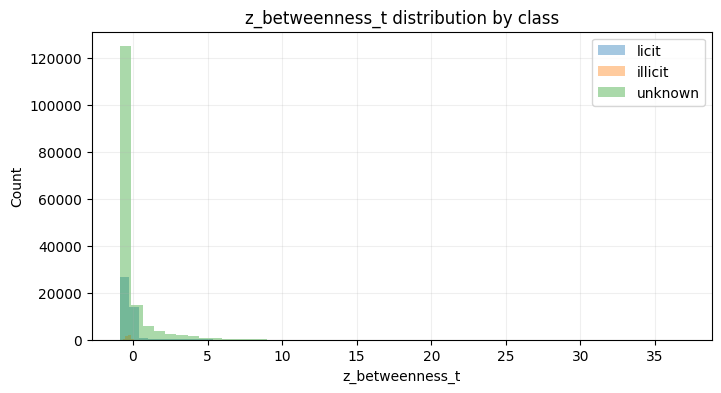

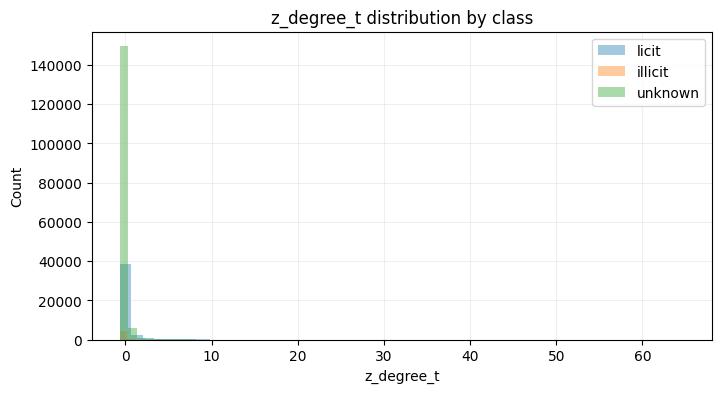

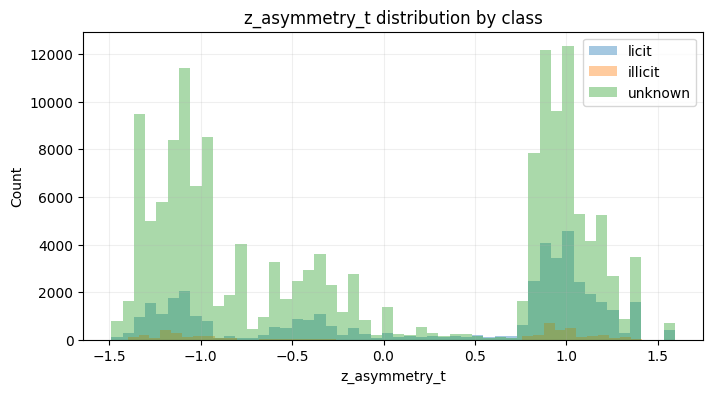

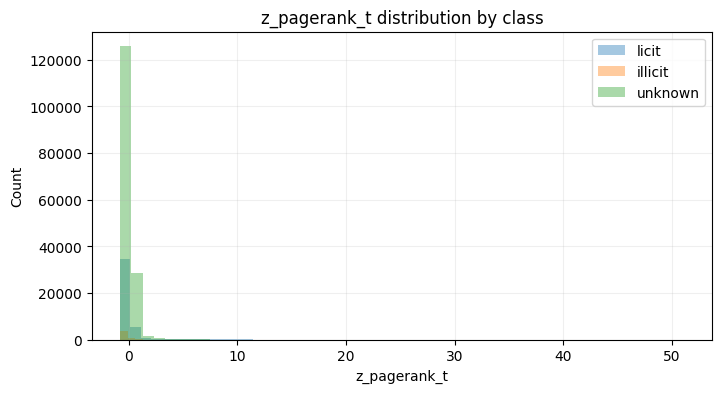

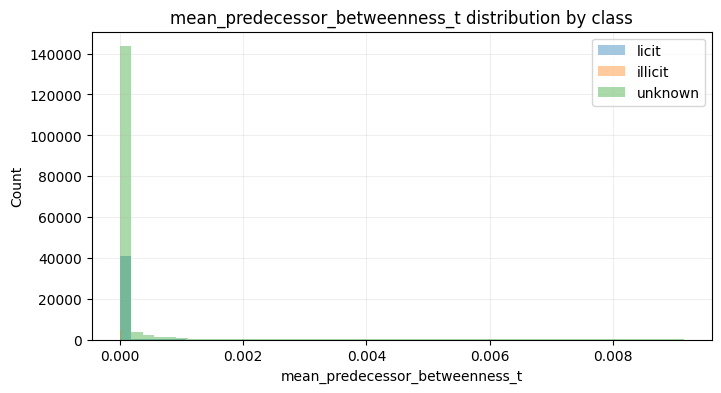

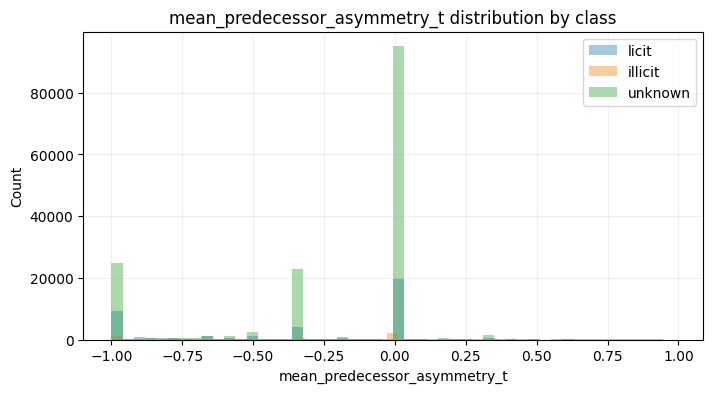

In [20]:
# three-way robustness check
plot_metrics = [
    "z_betweenness_t",
    "z_degree_t",
    "z_asymmetry_t",
    "z_pagerank_t",
    "mean_predecessor_betweenness_t",
    "mean_predecessor_asymmetry_t"
]

for metric in plot_metrics:
    plt.figure(figsize=(8, 4))
    for cls in ["licit", "illicit", "unknown"]:
        vals = ps3_df.loc[ps3_df[CLASS_LABEL_COL] == cls, metric].dropna()
        plt.hist(vals, bins=50, alpha=0.4, label=cls)
    plt.title(f"{metric} distribution by class")
    plt.xlabel(metric)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

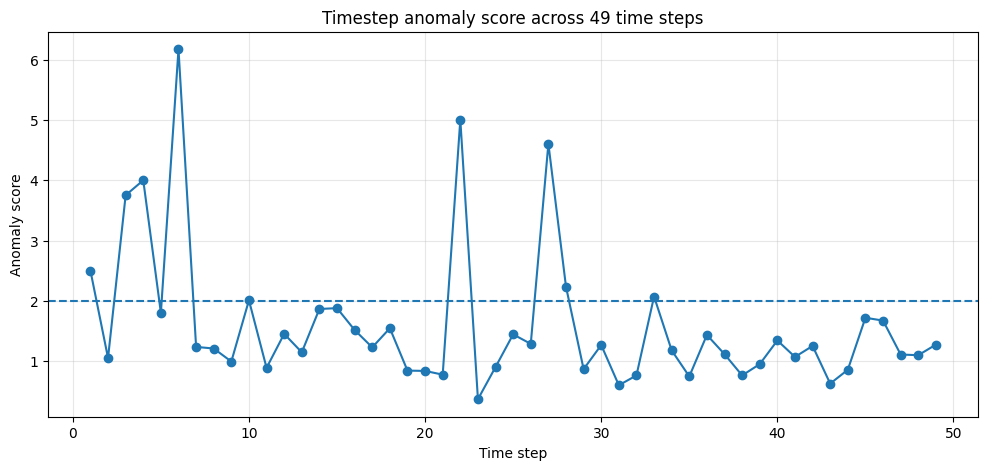

In [21]:
# line plot of timestep anomaly score
plt.figure(figsize=(12, 5))
plt.plot(timestep_eval_df[TIME_COL], timestep_eval_df["timestep_anomaly_score"], marker="o")
plt.axhline(ZSCORE_THRESHOLD, linestyle="--")
plt.title("Timestep anomaly score across 49 time steps")
plt.xlabel("Time step")
plt.ylabel("Anomaly score")
plt.grid(True, alpha=0.3)
plt.show()

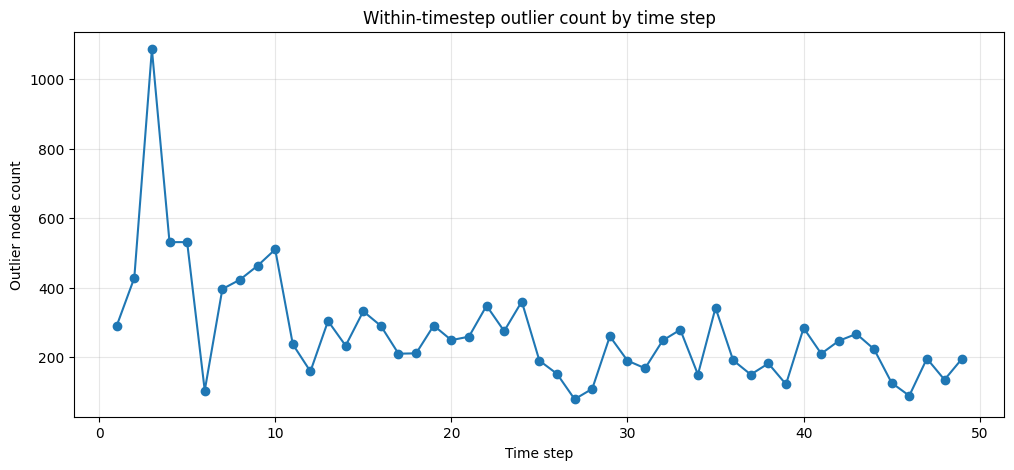

In [22]:
# outlier count by time step
plt.figure(figsize=(12, 5))
plt.plot(timestep_agg_df[TIME_COL], timestep_agg_df["outlier_node_count_t"], marker="o")
plt.title("Within-timestep outlier count by time step")
plt.xlabel("Time step")
plt.ylabel("Outlier node count")
plt.grid(True, alpha=0.3)
plt.show()